In [524]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [525]:
data = pd.read_csv("USDT-USD.csv")

In [526]:
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2017-11-09,1.01087,1.01327,0.996515,1.00818,1.00818,3.581880e+08
1,2017-11-10,1.00650,1.02423,0.995486,1.00601,1.00601,7.564460e+08
2,2017-11-11,1.00598,1.02621,0.995799,1.00899,1.00899,7.462280e+08
3,2017-11-12,1.00602,1.10591,0.967601,1.01247,1.01247,1.466060e+09
4,2017-11-13,1.00448,1.02929,0.975103,1.00935,1.00935,7.678840e+08


In [527]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1822 entries, 0 to 1821
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1822 non-null   str    
 1   Open       1821 non-null   float64
 2   High       1821 non-null   float64
 3   Low        1821 non-null   float64
 4   Close      1821 non-null   float64
 5   Adj Close  1821 non-null   float64
 6   Volume     1821 non-null   float64
dtypes: float64(6), str(1)
memory usage: 99.8 KB


In [528]:
data.shape

(1822, 7)

In [529]:
data = data.dropna()

In [530]:
data.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [531]:
data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='str')

In [532]:
data['year'] = [int(i.split('-')[0]) for i in data['Date'].values]
data['month'] = [int(i.split('-')[1]) for i in data['Date'].values]
data['day'] = [int(i.split('-')[2]) for i in data['Date'].values]

In [533]:
data.head(3)

,Date,Open,High,Low,Close,Adj Close,Volume,year,month,day
0,2017-11-09,1.01087,1.01327,0.996515,1.00818,1.00818,358188000.0,2017,11,9
1,2017-11-10,1.00650,1.02423,0.995486,1.00601,1.00601,756446016.0,2017,11,10
2,2017-11-11,1.00598,1.02621,0.995799,1.00899,1.00899,746227968.0,2017,11,11


In [534]:
data.info()

<class 'pandas.DataFrame'>
Index: 1821 entries, 0 to 1821
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1821 non-null   str    
 1   Open       1821 non-null   float64
 2   High       1821 non-null   float64
 3   Low        1821 non-null   float64
 4   Close      1821 non-null   float64
 5   Adj Close  1821 non-null   float64
 6   Volume     1821 non-null   float64
 7   year       1821 non-null   int64  
 8   month      1821 non-null   int64  
 9   day        1821 non-null   int64  
dtypes: float64(6), int64(3), str(1)
memory usage: 156.5 KB


In [535]:
c1 = data["year"].to_list()
c2 = data["month"].to_list()
c3 = data["day"].to_list()
c4 = data["Close"].to_list()
data = list(zip(c1,c2,c3,c4))

In [536]:
time_window = 30
X = []
y = []
for i in range(0, len(data) - time_window):
    X.append(np.reshape([data[j] for j in range(i,i+time_window)], -1).tolist())
    # print(X[:5])###
    y.append(data[i+time_window][-1])

In [537]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

In [538]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
prediction = model.predict(X_test)

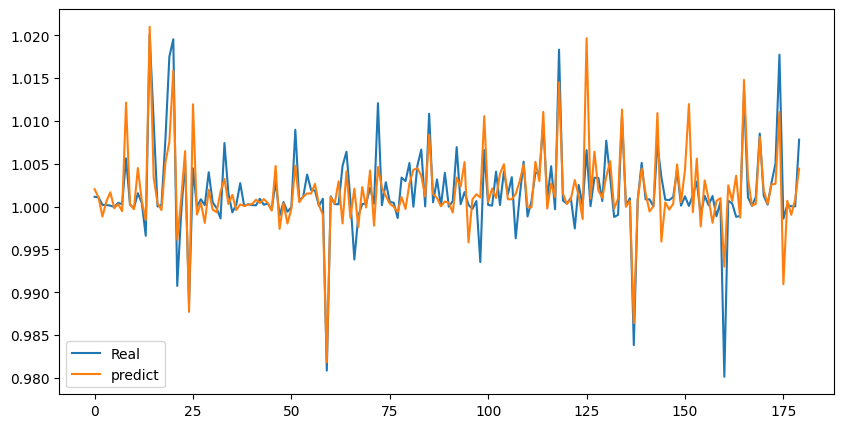

In [539]:
plt.figure(figsize=(10, 5))
plt.plot(y_test, label= "Real")
plt.plot(prediction, label= "predict")
plt.legend()
plt.show()

In [540]:
model.score(X_test, y_test)

0.6196963073528856